In [2]:
import sys
sys.path.append('..')  # add project root to Python path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load cleaned data using our preprocessing module
from src.data.preprocess import load_and_clean_data
X, y, _ = load_and_clean_data("../data/raw/credit_default.xls")
df = X.copy()
df['target'] = y

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 30000 rows, 24 columns


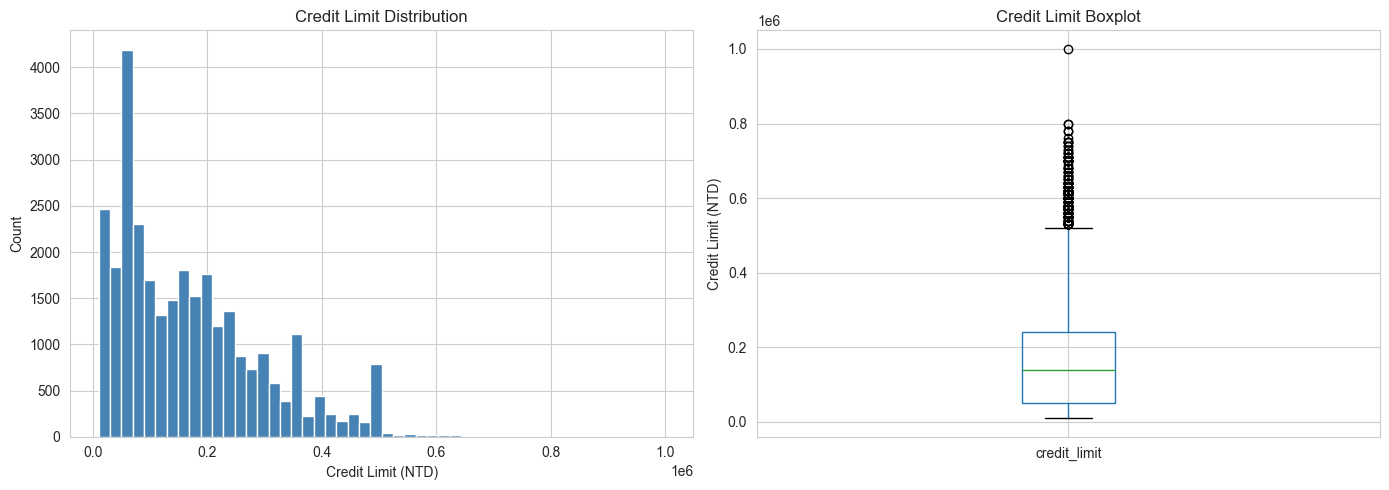

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df['credit_limit'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NTD)')
axes[0].set_ylabel('Count')

df.boxplot(column='credit_limit', ax=axes[1])
axes[1].set_title('Credit Limit Boxplot')
axes[1].set_ylabel('Credit Limit (NTD)')
plt.tight_layout()
plt.savefig("../data/processed/eda_credit_limit.png", dpi=150, bbox_inches='tight')
plt.show()

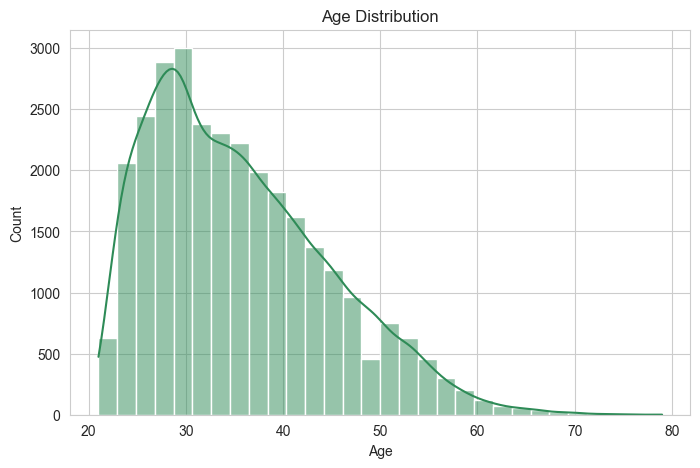

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='seagreen')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig("../data/processed/eda_age.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\TheSource\AppData\Local\Temp\ipykernel_5228\2820471303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pay_status_sept', data=df, palette='viridis')


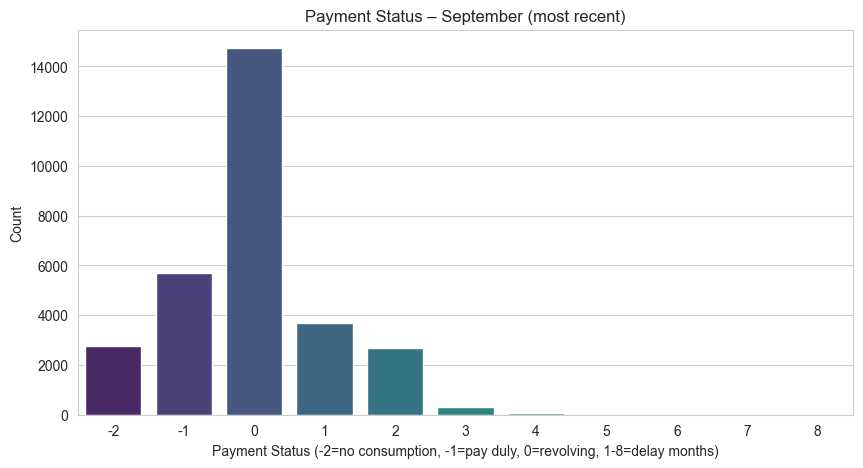

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(x='pay_status_sept', data=df, palette='viridis')
plt.title('Payment Status – September (most recent)')
plt.xlabel('Payment Status (-2=no consumption, -1=pay duly, 0=revolving, 1-8=delay months)')
plt.ylabel('Count')
plt.savefig("../data/processed/eda_pay_status_sept.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\TheSource\AppData\Local\Temp\ipykernel_5228\1232033143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='credit_limit', data=df, palette='Set2')


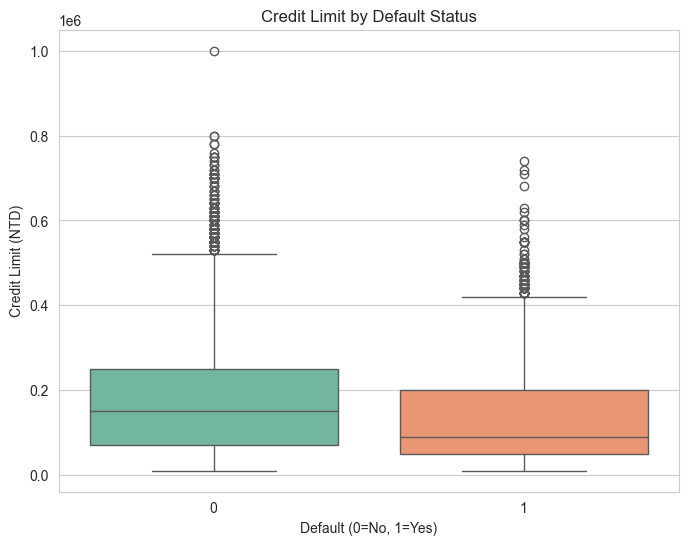

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target', y='credit_limit', data=df, palette='Set2')
plt.title('Credit Limit by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Credit Limit (NTD)')
plt.savefig("../data/processed/eda_box_credit_limit_target.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\TheSource\AppData\Local\Temp\ipykernel_5228\928513897.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='age', data=df, palette='Set2')


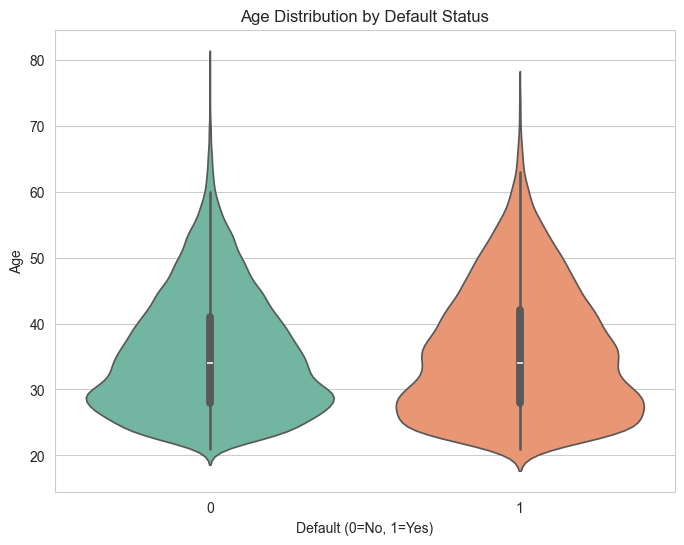

In [7]:
plt.figure(figsize=(8,6))
sns.violinplot(x='target', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Age')
plt.savefig("../data/processed/eda_violin_age_target.png", dpi=150, bbox_inches='tight')
plt.show()

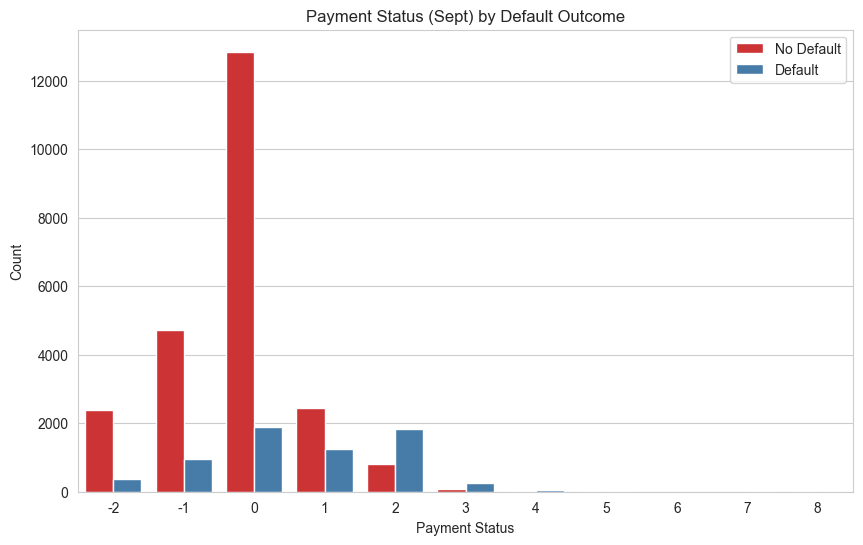

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(x='pay_status_sept', hue='target', data=df, palette='Set1')
plt.title('Payment Status (Sept) by Default Outcome')
plt.xlabel('Payment Status')
plt.ylabel('Count')
plt.legend(['No Default', 'Default'])
plt.savefig("../data/processed/eda_pay_status_target.png", dpi=150, bbox_inches='tight')
plt.show()

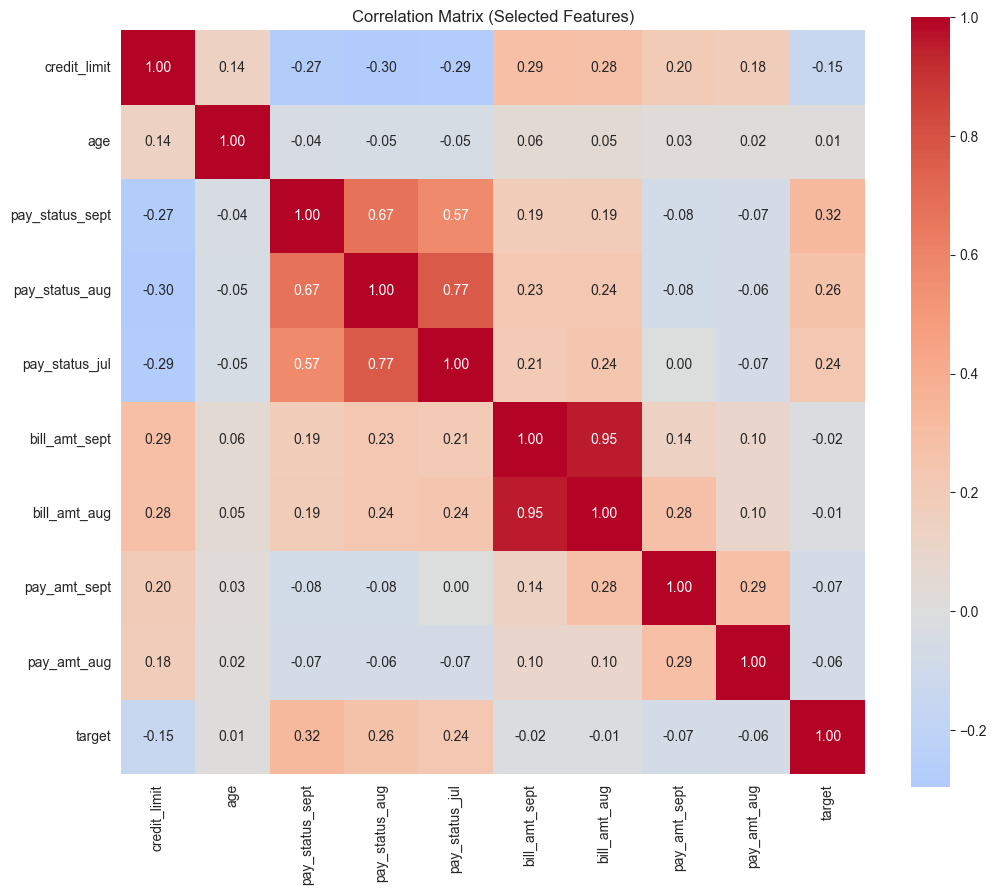

In [9]:
# Select a subset for readability
cols = ['credit_limit', 'age', 'pay_status_sept', 'pay_status_aug', 'pay_status_jul',
        'bill_amt_sept', 'bill_amt_aug', 'pay_amt_sept', 'pay_amt_aug', 'target']
corr = df[cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix (Selected Features)')
plt.savefig("../data/processed/eda_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

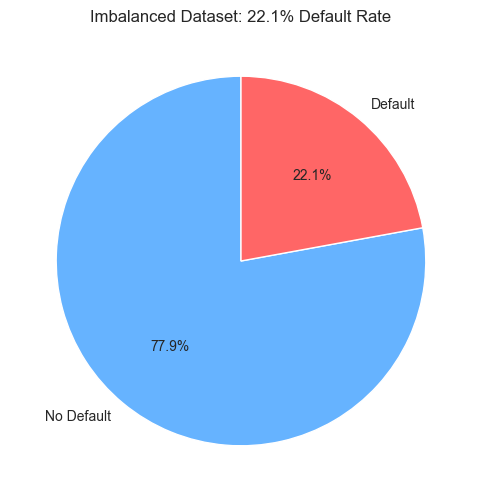

In [10]:
default_rate = df['target'].mean() * 100
plt.figure(figsize=(6,6))
plt.pie([100-default_rate, default_rate], labels=['No Default', 'Default'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title(f'Imbalanced Dataset: {default_rate:.1f}% Default Rate')
plt.savefig("../data/processed/eda_class_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Insights from EDA

- **Class Imbalance:** The dataset is moderately imbalanced with 22% defaults. We will need to handle this during modelling (SMOTE or class weighting).

- **Credit Limit:** Higher credit limits are slightly associated with lower default rates. The distribution is right‑skewed; scaling will be applied.

- **Age:** Younger individuals (20‑30) have a slightly higher default rate, but the effect is weak.

- **Payment Status:** The most recent payment status (September) is highly predictive: those with on‑time payment (-1 or 0) rarely default, while those in delay (1‑8) default much more often.

- **Bill Amounts:** High bill amounts in recent months correlate positively with default risk (visible in heatmap).

- **Correlation:** The heatmap shows moderate correlations between consecutive bill amounts, but no multicollinearity severe enough to break a linear model.

Overall, a tree‑based ensemble (XGBoost) is likely to perform well without extensive feature engineering beyond what we already have.